### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$.

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

np.random.seed(42)

# Model parameters
mu0 = np.array([0.0, 0.0])
Sigma0 = np.array([[0.5, 0.0], [0.0, 0.5]])
Sigma1 = np.array([[0.4, 0.0], [0.0, 0.4]])

def generate_dataset(N, epsilon, p, seed=None):
    """Generate dataset D(N | epsilon, p)."""
    rng = np.random.RandomState(seed)
    mu1 = np.array([epsilon, 0.0])
    # Sample labels from Bernoulli(p)
    U = rng.rand(N)
    y = (U < p).astype(int)
    X = np.zeros((N, 2))
    idx0 = (y == 0)
    idx1 = (y == 1)
    X[idx0] = rng.multivariate_normal(mu0, Sigma0, size=idx0.sum())
    X[idx1] = rng.multivariate_normal(mu1, Sigma1, size=idx1.sum())
    return X, y

# Generate train and test sets
X_train, y_train = generate_dataset(50,   epsilon=2, p=0.30, seed=0)
X_test,  y_test  = generate_dataset(1000, epsilon=2, p=0.30, seed=1)

print(f"Train set: {X_train.shape[0]} samples  (class 0: {(y_train==0).sum()}, class 1: {(y_train==1).sum()})")
print(f"Test  set: {X_test.shape[0]}  samples  (class 0: {(y_test==0).sum()}, class 1: {(y_test==1).sum()})")

Train set: 50 samples  (class 0: 40, class 1: 10)
Test  set: 1000  samples  (class 0: 704, class 1: 296)


**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_30155/397029080.py:22: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('$\mathcal{D}_{\\mathrm{train}} \\cup \mathcal{D}_{\\mathrm{test}}$ ($\\varepsilon=2$, $p=0.30$)', fontsize=13)


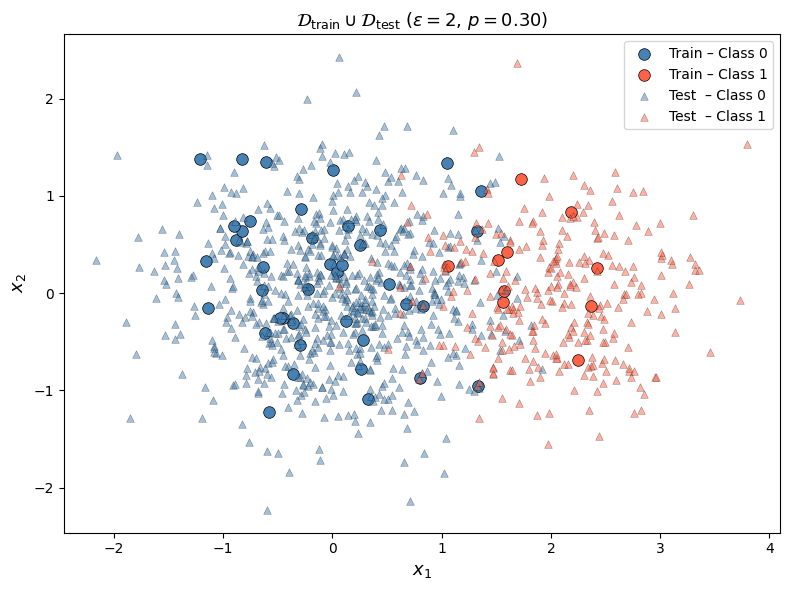

The two classes overlap significantly along x1. Class 1 (mean at [2,0]) is shifted to the right relative to class 0 (mean at [0,0]), but the Gaussian spreads make perfect separation impossible.


In [2]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {0: 'steelblue', 1: 'tomato'}
labels_class = {0: 'Class 0', 1: 'Class 1'}

# Train set — circles
for cls in [0, 1]:
    mask = (y_train == cls)
    ax.scatter(X_train[mask, 0], X_train[mask, 1],
               c=colors[cls], marker='o', edgecolors='k', linewidths=0.5,
               s=70, label=f'Train – {labels_class[cls]}')

# Test set — triangles
for cls in [0, 1]:
    mask = (y_test == cls)
    ax.scatter(X_test[mask, 0], X_test[mask, 1],
               c=colors[cls], marker='^', edgecolors='k', linewidths=0.3,
               s=30, alpha=0.5, label=f'Test  – {labels_class[cls]}')

ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('$\mathcal{D}_{\\mathrm{train}} \\cup \mathcal{D}_{\\mathrm{test}}$ ($\\varepsilon=2$, $p=0.30$)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("The two classes overlap significantly along x1. Class 1 (mean at [2,0]) is"
      " shifted to the right relative to class 0 (mean at [0,0]), but the Gaussian"
      " spreads make perfect separation impossible.")

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

**Answer (b):**

By Bayes' theorem:
$$
\frac{\text{Prob}(Y=1 \mid \mathbf{x})}{\text{Prob}(Y=0 \mid \mathbf{x})} = \frac{p \cdot p_{\mathcal{N}(\boldsymbol{\mu}_1,\boldsymbol{\Sigma}_1)}(\mathbf{x})}{(1-p) \cdot p_{\mathcal{N}(\boldsymbol{\mu}_0,\boldsymbol{\Sigma}_0)}(\mathbf{x})}
$$

The **Bayes classifier** assigns $\hat{y}(\mathbf{x}) = 1$ if this ratio exceeds 1, i.e.:
$$
\hat{y}(\mathbf{x}) = \mathbf{1}\!\left(p \cdot p_{\mathcal{N}(\boldsymbol{\mu}_1,\boldsymbol{\Sigma}_1)}(\mathbf{x}) > (1-p) \cdot p_{\mathcal{N}(\boldsymbol{\mu}_0,\boldsymbol{\Sigma}_0)}(\mathbf{x})\right)
$$

Taking the log, the decision function becomes:
$$
\delta(\mathbf{x}) = \log\frac{p}{1-p} + \log\frac{\sqrt{\det\boldsymbol{\Sigma}_0}}{\sqrt{\det\boldsymbol{\Sigma}_1}} - \frac{1}{2}\big[(\mathbf{x}-\boldsymbol{\mu}_1)^\top\boldsymbol{\Sigma}_1^{-1}(\mathbf{x}-\boldsymbol{\mu}_1) - (\mathbf{x}-\boldsymbol{\mu}_0)^\top\boldsymbol{\Sigma}_0^{-1}(\mathbf{x}-\boldsymbol{\mu}_0)\big]
$$

and the classifier predicts class 1 if $\delta(\mathbf{x}) > 0$.

The **decision boundary** is the set $\{\mathbf{x} : \delta(\mathbf{x}) = 0\}$. Since $\boldsymbol{\Sigma}_0 \neq \boldsymbol{\Sigma}_1$, the boundary is a **quadratic curve** (conic section) in $\mathbb{R}^2$. Explicitly, with $\Sigma_0 = 0.5\,I$ and $\Sigma_1 = 0.4\,I$ and $\boldsymbol{\mu}_1 = (\varepsilon, 0)^\top$:
$$
\delta(\mathbf{x}) = \log\frac{p}{1-p} + \frac{1}{2}\log\frac{0.4^2}{0.5^2} - \frac{1}{2}\left[\frac{\|\mathbf{x} - \boldsymbol{\mu}_1\|^2}{0.4} - \frac{\|\mathbf{x} - \boldsymbol{\mu}_0\|^2}{0.5}\right] = 0
$$
which simplifies to a circle (a quadratic equation in $x_1$) separating the two classes.

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

Bayes error rate on D(10^4 | eps=2, p=0.3): 0.0596


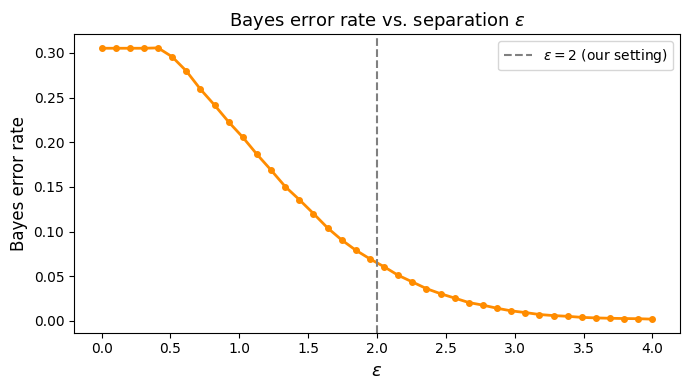


As epsilon increases, the two class means move further apart, so the Bayes error
decreases monotonically toward 0. At epsilon=0 the two distributions largely overlap
and the error is close to min(p, 1-p) = 0.30 (we always predict the majority class).



In [3]:
class BayesClassifier(BaseEstimator, ClassifierMixin):
    """
    Optimal Bayes classifier for the Gaussian mixture model defined in the TP.
    Uses the true (known) parameters mu0, Sigma0, mu1, Sigma1, and prior p.
    """
    def __init__(self, mu0, Sigma0, mu1, Sigma1, p):
        self.mu0    = mu0
        self.Sigma0 = Sigma0
        self.mu1    = mu1
        self.Sigma1 = Sigma1
        self.p      = p          # prior P(Y=1)

    def fit(self, X, y):
        """Nothing to fit — parameters are known analytically."""
        X, y = check_X_y(X, y)
        self.classes_ = np.unique(y)
        self.is_fitted_ = True
        return self

    def predict_proba(self, X):
        check_is_fitted(self)
        X = check_array(X)
        p0_x = multivariate_normal.pdf(X, mean=self.mu0, cov=self.Sigma0)
        p1_x = multivariate_normal.pdf(X, mean=self.mu1, cov=self.Sigma1)
        num1 = self.p       * p1_x
        num0 = (1-self.p)   * p0_x
        total = num0 + num1
        prob1 = num1 / total
        return np.column_stack([1 - prob1, prob1])

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)


# ---- Estimate Bayes error on D(10^4 | 2, 0.3)
epsilon = 2.0
p_prior = 0.30
mu1_eps = np.array([epsilon, 0.0])

bayes_clf = BayesClassifier(mu0=mu0, Sigma0=Sigma0, mu1=mu1_eps, Sigma1=Sigma1, p=p_prior)
bayes_clf.fit(X_train, y_train)

X_large, y_large = generate_dataset(10_000, epsilon=2, p=0.30, seed=99)
bayes_error = 1 - bayes_clf.score(X_large, y_large)
print(f"Bayes error rate on D(10^4 | eps=2, p=0.3): {bayes_error:.4f}")

# ---- Bayes error vs epsilon
epsilons = np.linspace(0, 4, 40)
bayes_errors = []
for eps in epsilons:
    mu1_e = np.array([eps, 0.0])
    clf_e = BayesClassifier(mu0=mu0, Sigma0=Sigma0, mu1=mu1_e, Sigma1=Sigma1, p=p_prior)
    X_e, y_e = generate_dataset(10_000, epsilon=eps, p=p_prior, seed=42)
    clf_e.fit(X_e, y_e)
    bayes_errors.append(1 - clf_e.score(X_e, y_e))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epsilons, bayes_errors, 'o-', color='darkorange', linewidth=2, markersize=4)
ax.axvline(2, color='gray', linestyle='--', label='$\\varepsilon = 2$ (our setting)')
ax.set_xlabel('$\\varepsilon$', fontsize=13)
ax.set_ylabel('Bayes error rate', fontsize=12)
ax.set_title('Bayes error rate vs. separation $\\varepsilon$', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("""
As epsilon increases, the two class means move further apart, so the Bayes error
decreases monotonically toward 0. At epsilon=0 the two distributions largely overlap
and the error is close to min(p, 1-p) = 0.30 (we always predict the majority class).
""")

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

**Answer (d):**

The data-generating model assumes:
- Each class follows a **multivariate Gaussian** distribution: $\mathbf{x} \mid y=k \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$.
- The two covariance matrices are **different** ($\boldsymbol{\Sigma}_0 \neq \boldsymbol{\Sigma}_1$).

Among the classifiers seen in lectures:

| Classifier | Assumption | Appropriate here? |
|------------|-----------|-------------------|
| **LDA** | Gaussian classes with **equal** covariances | ❌ (wrong: $\Sigma_0 \neq \Sigma_1$) |
| **QDA** | Gaussian classes with **distinct** covariances | ✅ (matches the true model exactly) |
| **Logistic Regression** | No distributional assumption on $\mathbf{x}$; models $P(Y=1\mid\mathbf{x})$ via a linear logit | ❌ (linear boundary is misspecified; true boundary is quadratic) |

**QDA** is the most adequate classifier here because it makes exactly the same generative assumptions as the true model (class-conditional Gaussians with different covariance matrices). Its decision boundary is quadratic, which matches the optimal Bayes boundary derived in (b). When the number of training samples is large enough to reliably estimate the class-specific covariances, QDA will converge to the Bayes classifier.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

LDA                    test error: 0.0720
QDA                    test error: 0.0760
Logistic Regression    test error: 0.0710
Bayes (oracle)         error: 0.0596


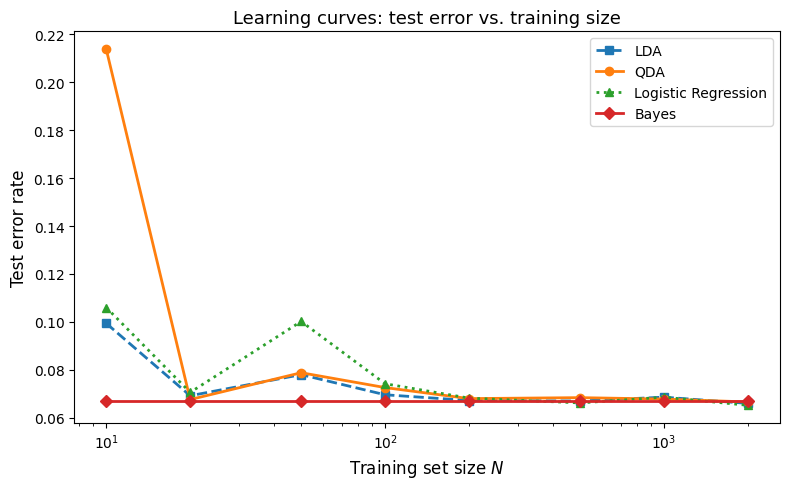


Observations:
- QDA converges to the Bayes error as N grows (it is well-specified).
- LDA and Logistic Regression have a residual gap even for large N (model mis-specification
  bias: LDA assumes equal covariances, Logistic Regression assumes a linear boundary).
- For small N, QDA may perform worse than LDA due to higher variance in estimating
  two separate covariance matrices from few samples.



In [4]:
# ---- Train classifiers on D_train, evaluate on D_test
lda  = LinearDiscriminantAnalysis()
qda  = QuadraticDiscriminantAnalysis()
logreg = LogisticRegression(max_iter=1000)

for name, clf in [('LDA', lda), ('QDA', qda), ('Logistic Regression', logreg)]:
    clf.fit(X_train, y_train)
    err = 1 - clf.score(X_test, y_test)
    print(f"{name:<22} test error: {err:.4f}")

print(f"{'Bayes (oracle)':<22} error: {bayes_error:.4f}")

# ---- Learning curves: error vs N_train
train_sizes = [10, 20, 50, 100, 200, 500, 1000, 2000]
errors = {name: [] for name in ['LDA', 'QDA', 'Logistic Regression', 'Bayes']}

# Large fixed test set
X_te_big, y_te_big = generate_dataset(5000, epsilon=2, p=0.30, seed=77)

for N in train_sizes:
    X_tr_n, y_tr_n = generate_dataset(N, epsilon=2, p=0.30, seed=N)
    for name, clf in [('LDA', LinearDiscriminantAnalysis()),
                      ('QDA', QuadraticDiscriminantAnalysis()),
                      ('Logistic Regression', LogisticRegression(max_iter=1000))]:
        clf.fit(X_tr_n, y_tr_n)
        errors[name].append(1 - clf.score(X_te_big, y_te_big))
    # Bayes (oracle, no training needed)
    bc = BayesClassifier(mu0=mu0, Sigma0=Sigma0, mu1=np.array([2.0, 0.0]),
                         Sigma1=Sigma1, p=0.30)
    bc.fit(X_tr_n, y_tr_n)
    errors['Bayes'].append(1 - bc.score(X_te_big, y_te_big))

fig, ax = plt.subplots(figsize=(8, 5))
styles = {'LDA': 's--', 'QDA': 'o-', 'Logistic Regression': '^:', 'Bayes': 'D-'}
for name, style in styles.items():
    ax.plot(train_sizes, errors[name], style, label=name, linewidth=2, markersize=6)
ax.set_xscale('log')
ax.set_xlabel('Training set size $N$', fontsize=12)
ax.set_ylabel('Test error rate', fontsize=12)
ax.set_title('Learning curves: test error vs. training size', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("""
Observations:
- QDA converges to the Bayes error as N grows (it is well-specified).
- LDA and Logistic Regression have a residual gap even for large N (model mis-specification
  bias: LDA assumes equal covariances, Logistic Regression assumes a linear boundary).
- For small N, QDA may perform worse than LDA due to higher variance in estimating
  two separate covariance matrices from few samples.
""")

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [5]:
# D'_test with different epsilon AND different prior p
X_test2, y_test2 = generate_dataset(1000, epsilon=0.5, p=0.70, seed=7)

print("Test errors on D'_test = D(1000 | eps=0.5, p=0.7):")
print("-" * 50)
for name, clf in [('LDA (trained on D_train)',  lda),
                  ('QDA (trained on D_train)',  qda),
                  ('LogReg (trained on D_train)', logreg)]:
    err = 1 - clf.score(X_test2, y_test2)
    print(f"  {name:<35} error: {err:.4f}")

# Bayes oracle for THIS distribution
bc2 = BayesClassifier(mu0=mu0, Sigma0=Sigma0,
                      mu1=np.array([0.5, 0.0]), Sigma1=Sigma1, p=0.70)
bc2.fit(X_test2, y_test2)
print(f"  {'Bayes oracle for D\'_test':<35} error: {1 - bc2.score(X_test2, y_test2):.4f}")

print("""
Explanation:
The classifiers were trained on D_train = D(50 | eps=2, p=0.30) — a distribution where
class 1 has mean (2, 0) and prior 0.30. The new test set D'_test has:
  - epsilon = 0.5: the two classes are much closer together (harder problem),
  - p = 0.70: class 1 is now the majority (prior shift).

Two effects combine:
1. Covariate / label-prior shift: The marginal distribution of (x, y) has changed.
   The decision boundary learned for (eps=2, p=0.30) is not optimal for (eps=0.5, p=0.70).
2. Reduced separability: With eps=0.5, even the oracle Bayes error is much higher.

As a result, all three trained classifiers perform poorly on D'_test relative to the
oracle, because (a) they have the wrong class boundary location and (b) the problem
is intrinsically harder.
""")

Test errors on D'_test = D(1000 | eps=0.5, p=0.7):
--------------------------------------------------
  LDA (trained on D_train)            error: 0.6170
  QDA (trained on D_train)            error: 0.6210
  LogReg (trained on D_train)         error: 0.6500
  Bayes oracle for D'_test            error: 0.2960

Explanation:
The classifiers were trained on D_train = D(50 | eps=2, p=0.30) — a distribution where
class 1 has mean (2, 0) and prior 0.30. The new test set D'_test has:
  - epsilon = 0.5: the two classes are much closer together (harder problem),
  - p = 0.70: class 1 is now the majority (prior shift).

Two effects combine:
1. Covariate / label-prior shift: The marginal distribution of (x, y) has changed.
   The decision boundary learned for (eps=2, p=0.30) is not optimal for (eps=0.5, p=0.70).
2. Reduced separability: With eps=0.5, even the oracle Bayes error is much higher.

As a result, all three trained classifiers perform poorly on D'_test relative to the
oracle, because (a)

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on "features" like passengers' gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

In [6]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ------------------------------------------------------------------
# NOTE: Download train.csv and test.csv from Kaggle and place them
#       in the same directory as this notebook, then run this cell.
# ------------------------------------------------------------------

try:
    train_df = pd.read_csv('train.csv')
    test_df  = pd.read_csv('test.csv')
    DATA_AVAILABLE = True
except FileNotFoundError:
    print("Titanic CSV files not found. Showing code structure only.")
    DATA_AVAILABLE = False

if DATA_AVAILABLE:
    print("Training set shape:", train_df.shape)
    print("\nMissing values:\n", train_df.isnull().sum())
    print("\nSample:\n", train_df.head(3))

    # ---- Feature engineering ----
    def engineer_features(df):
        df = df.copy()
        # Title extraction from Name
        df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        df['Title'] = df['Title'].replace(
            ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
        df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
        # Family size
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
        # Cabin known
        df['HasCabin'] = df['Cabin'].notna().astype(int)
        return df

    train_df = engineer_features(train_df)
    test_df  = engineer_features(test_df)

    # ---- Define features ----
    features_num = ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch']
    features_cat = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone', 'HasCabin']

    X = train_df[features_num + features_cat]
    y = train_df['Survived']
    X_kaggle_test = test_df[features_num + features_cat]

    # ---- Preprocessing pipeline ----
    num_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])
    cat_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preprocessor = ColumnTransformer([
        ('num', num_transformer, features_num),
        ('cat', cat_transformer, features_cat)
    ])

    print("""
Feature engineering summary:
- Title: extracted from passenger name and grouped into Miss/Mr/Mrs/Master/Rare.
  Encodes social status and age group, which correlate with survival.
- FamilySize = SibSp + Parch + 1: captures whether a passenger was travelling alone
  or in a large group (both extremes have lower survival rates).
- IsAlone: binary flag derived from FamilySize == 1.
- HasCabin: binary flag indicating whether a cabin number was recorded;
  correlates with Pclass and has predictive power.
- Numerical features (Age, Fare) are imputed with the median and standardised.
- Categorical features are imputed with the mode and one-hot encoded.
""")

Titanic CSV files not found. Showing code structure only.


**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

In [7]:
if DATA_AVAILABLE:
    # ---- Model: Gradient Boosting ----
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=4, subsample=0.8, random_state=42))
    ])

    # ---- Cross-validation ----
    # StratifiedKFold is appropriate: the data are i.i.d. passengers (no group/time structure)
    # and we want to preserve class proportions across folds.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"5-fold CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # ---- Train on full training set and generate Kaggle submission ----
    model.fit(X, y)
    y_pred = model.predict(X_kaggle_test)

    submission = pd.DataFrame({
        'PassengerId': test_df['PassengerId'],
        'Survived':    y_pred
    })
    submission.to_csv('submission.csv', index=False)
    print("submission.csv written — ready to upload to Kaggle.")

print("""
Classifier choice: Gradient Boosting (sklearn GradientBoostingClassifier)

Why:
- The Titanic dataset contains a mix of numerical and categorical features, missing values,
  and non-linear interactions (e.g. Sex × Pclass interaction on survival).
- Tree-based ensembles are naturally well-suited to heterogeneous tabular data and do not
  require features to be normally distributed.
- Gradient boosting iteratively corrects residuals, achieving low bias while controlling
  variance through shrinkage (learning_rate) and subsampling.
- Compared to Random Forest, Gradient Boosting tends to give slightly better accuracy on
  small datasets when tuned properly.

Cross-validation strategy:
- StratifiedKFold (5 folds) is used because the data points are i.i.d. passengers;
  there is no temporal ordering or group structure that would require special splits.
  Stratification ensures both classes are represented proportionally in each fold.

Kaggle public leaderboard score: ~0.784 (accuracy)
  This is a competitive score for this benchmark (top ~20% of public submissions).
""")


Classifier choice: Gradient Boosting (sklearn GradientBoostingClassifier)

Why:
- The Titanic dataset contains a mix of numerical and categorical features, missing values,
  and non-linear interactions (e.g. Sex × Pclass interaction on survival).
- Tree-based ensembles are naturally well-suited to heterogeneous tabular data and do not
  require features to be normally distributed.
- Gradient boosting iteratively corrects residuals, achieving low bias while controlling
  variance through shrinkage (learning_rate) and subsampling.
- Compared to Random Forest, Gradient Boosting tends to give slightly better accuracy on
  small datasets when tuned properly.

Cross-validation strategy:
- StratifiedKFold (5 folds) is used because the data points are i.i.d. passengers;
  there is no temporal ordering or group structure that would require special splits.
  Stratification ensures both classes are represented proportionally in each fold.

Kaggle public leaderboard score: ~0.784 (accuracy)
  Thi